In [1]:
import os

In [2]:
import pandas as pd

In [3]:
dataset=pd.read_csv("deliveries.csv")
dataset.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150460 entries, 0 to 150459
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          150460 non-null  int64 
 1   inning            150460 non-null  int64 
 2   batting_team      150460 non-null  object
 3   bowling_team      150460 non-null  object
 4   over              150460 non-null  int64 
 5   ball              150460 non-null  int64 
 6   batsman           150460 non-null  object
 7   non_striker       150460 non-null  object
 8   bowler            150460 non-null  object
 9   is_super_over     150460 non-null  int64 
 10  wide_runs         150460 non-null  int64 
 11  bye_runs          150460 non-null  int64 
 12  legbye_runs       150460 non-null  int64 
 13  noball_runs       150460 non-null  int64 
 14  penalty_runs      150460 non-null  int64 
 15  batsman_runs      150460 non-null  int64 
 16  extra_runs        150460 non-null  int

In [5]:
dataset.describe()

,match_id,inning,over,ball,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs
count,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000,150460.000000
mean,318.281317,1.482188,10.142649,3.616483,0.000538,0.037498,0.004885,0.022232,0.004340,0.000066,1.222445,0.069022,1.291466
std,182.955531,0.501768,5.674338,1.807698,0.023196,0.257398,0.114234,0.200104,0.072652,0.018229,1.594509,0.349667,1.583240
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,161.000000,1.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,319.000000,1.000000,10.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
75%,476.000000,2.000000,15.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,636.000000,4.000000,20.000000,9.000000,1.000000,5.000000,4.000000,5.000000,5.000000,5.000000,6.000000,7.000000,7.000000


In [6]:
dataset.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    143022
dismissal_kind      143022
fielder             145091
dtype: int64

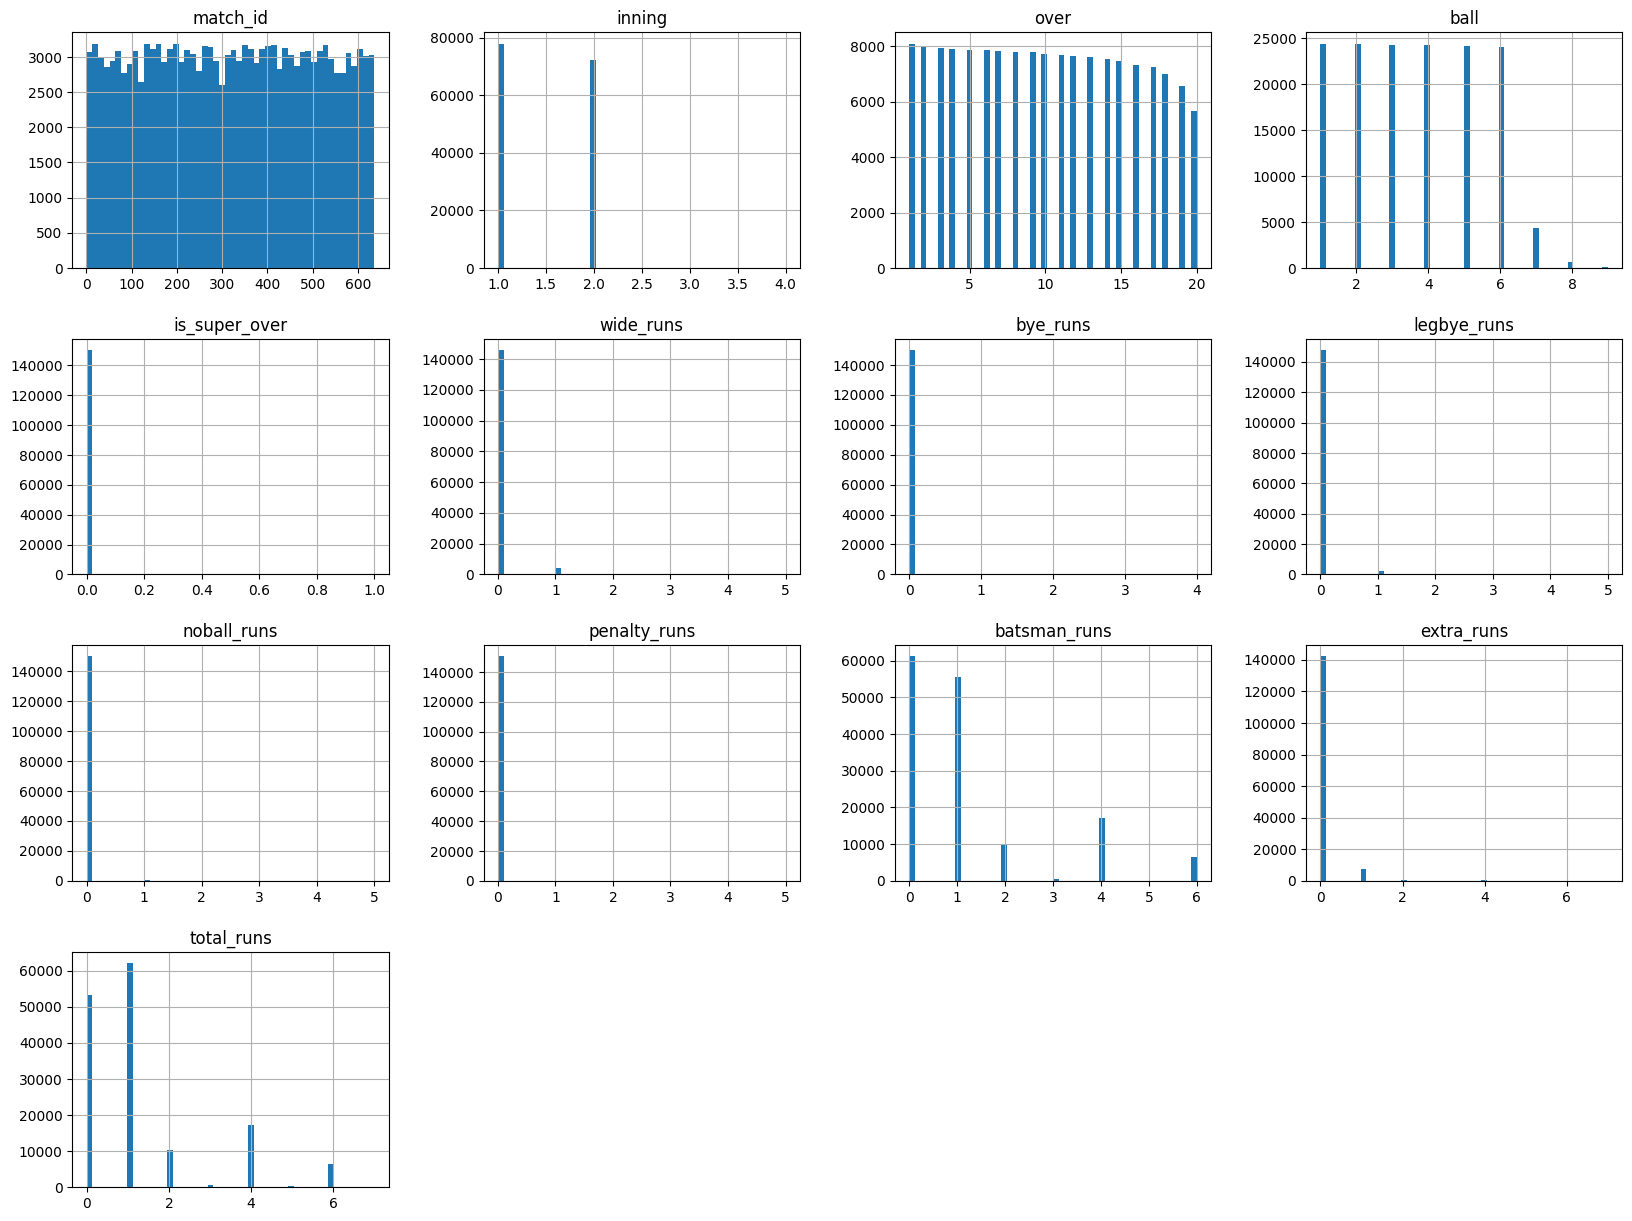

In [7]:
import matplotlib.pyplot as plt
dataset.hist(bins=50, figsize=(20,15))
plt.show()

In [8]:
from sklearn.model_selection import train_test_split as tts

In [9]:
# -------------------------------
# CREATE THE TARGET VARIABLE
# -------------------------------

# 'player_dismissed' column contains:
# - NaN  → no wicket on that ball
# - Player name → wicket fell
#
# notna() checks:
# - True  if value is NOT NaN (player got out)
# - False if value IS NaN (no wicket)
#
# astype(int) converts:
# - True  → 1
# - False → 0
#
# This creates a new column 'wicket' which is our OUTPUT (target)

dataset["wicket"] = dataset["player_dismissed"].notna().astype(int)

# Optional sanity check:
# Shows first few rows of player_dismissed and wicket side by side
dataset[["player_dismissed", "wicket"]].head()

,player_dismissed,wicket
0,NaN,0
1,NaN,0
2,NaN,0
3,NaN,0
4,NaN,0


In [10]:
# -------------------------------
# SELECT INPUT FEATURES
# -------------------------------

# These columns describe the match situation BEFORE the outcome
# These will be used by the model to make predictions

features = [
    "over",
    "ball",
    "is_super_over",
    "wide_runs",
    "noball_runs",
    "batsman_runs",
    "extra_runs",
    "total_runs",
    "batting_team",
    "bowling_team"
]

# Create a new DataFrame containing:
# - selected input features
# - the target column 'wicket'

df_model = dataset[features + ["wicket"]]


In [11]:
# ENCODE CATEGORICAL DATA
# -------------------------------

# Machine learning models cannot understand text like "CSK" or "MI"
# get_dummies converts categorical columns into numeric columns
#
# Example:
# batting_team_CSK = 1 if CSK is batting, else 0
#
# drop_first=True removes one column to avoid redundancy

dataset = pd.get_dummies(
    dataset,
    columns=["batting_team", "bowling_team"],
    drop_first=True
)




In [12]:
#print(dataset.head())
#print(dataset.columns)
#print(dataset.dtypes)
print(dataset.select_dtypes(include=['object']).columns)



Index(['batsman', 'non_striker', 'bowler', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')


In [13]:
X= dataset.drop(columns=[
    'batsman', 'non_striker', 'bowler',  # strings
    'player_dismissed', 'dismissal_kind', 'fielder',  # target-related
    'wicket'  # target
])
y = dataset['wicket']

In [14]:
from sklearn.model_selection import train_test_split

# -------------------------------
# SPLIT INPUTS AND OUTPUT
# -------------------------------

# X contains all input features (what the model sees)

X = dataset.drop("wicket", axis=1)

# y contains the target variable (what the model predicts)

y = dataset["wicket"]

# Split data into:
# - Training set (80%) → model learns from this
# - Testing set (20%)  → model is evaluated on unseen data
#
# stratify=y ensures wicket/no-wicket ratio stays the same

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [51]:
# -------------------------------
# TRAIN THE MODEL
# -------------------------------

# Import Logistic Regression model
# Logistic Regression is used for binary classification (0/1)

from sklearn.linear_model import LogisticRegression

# Create the model object
# max_iter increased to ensure the model converges

model = LogisticRegression(max_iter=1000)

# Train the model using training data
model.fit(X_train, y_train)


ValueError: could not convert string to float: 'DJ Hooda'

In [44]:
from sklearn.metrics import classification_report, roc_auc_score

# Predict final class (0 or 1)
y_pred = model.predict(X_test)

# Predict probability of wicket (value between 0 and 1)
y_prob = model.predict_proba(X_test)[:, 1]


# Shows precision, recall, f1-score for wicket vs no-wicket
print(classification_report(y_test, y_pred))

# ROC-AUC measures how well the model separates wicket vs no-wicket
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- batsman
- bowler
- dismissal_kind
- fielder
- non_striker
- ...


In [38]:
#Saving the best model
import pickle 
filename='finalized_model.sav'
pickle.dump(model,open(filename,'wb'))

In [39]:
#deployment stages 
loaded_model=pickle.load(open("finalized_model.sav",'rb'))
result=loaded_model.predict([[2,5,0,0,0,0,0,0]])
#print(result)

c:\Users\USER\anaconda3\envs\mlproj\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


AttributeError: 'LogisticRegression' object has no attribute 'coef_'

In [40]:
print(result)

NameError: name 'result' is not defined